# Load Dependencies


## Files needed to run:

- `feature_columns.pkl`
- `svm_finetuned.pkl`
- `rf_finetuned.pkl`
- `CBERT_checkpoint.pth`
- `EnsembleProcessing.py`
- All files are available in the Final Implementation folder of our [repository](https://github.com/MiguelPartosa/Thesis-FOS-BinaryClass-WSD).


In [1]:
import pandas as pd
import torch
from torch import cuda
from transformers import DistilBertTokenizer, DistilBertModel

c:\Users\User\miniconda3\envs\data_science\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## CBERT Checkpoint


In [ ]:
device = 'cuda' if cuda.is_available() else 'cpu'


class BertClass(torch.nn.Module):
    def __init__(self):
        '''Loads the pretrained model CBERT.'''
        super(BertClass, self).__init__()
        self.l1 = DistilBertModel.from_pretrained('GianTan/CBERTo')
        self.pre_classifier = torch.nn.Linear(768, 768)
        self.dropout = torch.nn.Dropout(0.3)

        self.pre_classifier2 = torch.nn.Linear(768, 768)
        self.dropout2 = torch.nn.Dropout(0.3)

        self.classifier = torch.nn.Linear(768, 1)

    def forward(self, input_ids, attention_mask, token_type_ids):
        '''Feed forward function'''
        output_1 = self.l1(input_ids=input_ids, attention_mask=attention_mask)
        hidden_state = output_1[0]
        pooler = hidden_state[:, 0]
        pooler = self.pre_classifier(pooler)
        pooler = torch.nn.Tanh()(pooler)
        pooler = self.dropout(pooler)
        pooler = self.pre_classifier2(pooler)
        pooler = torch.nn.Tanh()(pooler)
        pooler = self.dropout2(pooler)

        output = self.classifier(pooler)
        return output.squeeze(1)

# Setting the bert model and utilizing the gpu
cbert_model = BertClass()
cbert_model.to(device)

# Loads the tokenizer
tokenizer = DistilBertTokenizer.from_pretrained(
    'GianTan/CBERTo', truncation=True, do_lower_case=False)
optimizer = torch.optim.Adam(params=cbert_model.parameters(), lr=4e-05)

# load
checkpoint = torch.load('CBERT_checkpoint.pth', map_location='cpu')
cbert_model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

## SVM and Random Forest Checkpoint


Importing


In [ ]:
import pickle
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

# Dependencies from read pickle file
def GetTextCol(X):
    text_cols = X.select_dtypes(include=['object', 'string']).columns
    if len(text_cols) == 0:
        raise ValueError("No text columns found in input DataFrame")
    # Error is raised if the first index is not returned.
    return text_cols[0]

# 
def GetNumCol(X):
    return X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Preprocessor functions pipeline for the ensemble model
preprocessor = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(), GetTextCol),
        ("scaler", StandardScaler(), GetNumCol)
    ],
    remainder='drop'  # Remove any unhandled columns
)

# SVM
with open('svm_finetuned.pkl', 'rb') as f:
    svm_best = pickle.load(f)

# Random Forest
with open('rf_finetuned.pkl', 'rb') as f:
    rf_best = pickle.load(f)

c:\Users\User\miniconda3\envs\data_science\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\User\miniconda3\envs\data_science\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\User\miniconda3\envs\data_science\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.

# Model Function Backend


## CBERT


In [ ]:
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm


class FOS_Classification(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        '''Variables set here are the columns usage and is_fos for classification'''
        self.tokenizer = tokenizer
        self.data = dataframe
        self.text = dataframe.Usage
        self.targets = self.data.is_fos
        self.max_len = max_len

    def __len__(self):
        return len(self.text)

    def __getitem__(self, index):
        text = str(self.text[index])
        text = " ".join(text.split())

        inputs = self.tokenizer.encode_plus(
            text,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            truncation=True,
            pad_to_max_length=True,
            return_token_type_ids=True
        )
        ids = inputs['input_ids']
        mask = inputs['attention_mask']
        token_type_ids = inputs["token_type_ids"]

        return {
            'ids': torch.tensor(ids, dtype=torch.long),
            'mask': torch.tensor(mask, dtype=torch.long),
            'token_type_ids': torch.tensor(token_type_ids, dtype=torch.long),
            'targets': torch.tensor(self.targets[index], dtype=torch.float)
        }

In [ ]:
# Function taken from Cbert train file to calculate multiple predictions from a dataframe

# Hyperparmeters loaded from original
test_params = {'batch_size': 128,
               'shuffle': True,
               'num_workers': 0
               }

# Load dataframe into prereq functions
def validation(df):
    '''
    Input df to return preds in array. 
    ## Requires:
    - 'is_fos' column with values (0,1) to work. 
    - 'Usage' column with the sentence to be processed.

    ## Outputs:
    - We are only concerened with the fin_outputs for experimentation usage
    '''
    testing_set = FOS_Classification(df, tokenizer, 256)
    testing_loader = DataLoader(testing_set, **test_params)
    cbert_model.eval()
    fin_targets = []
    fin_outputs = []

    with torch.no_grad():
        for _, data in tqdm(enumerate(testing_loader, 0)):
            ids = data['ids'].to(device, dtype=torch.long)
            mask = data['mask'].to(device, dtype=torch.long)
            token_type_ids = data['token_type_ids'].to(
                device, dtype=torch.long)
            targets = data['targets'].to(device, dtype=torch.float)
            outputs = cbert_model(ids, mask, token_type_ids)
            fin_targets.extend(targets.cpu().detach().numpy().tolist())
            fin_outputs.extend(torch.sigmoid(
                outputs).cpu().detach().numpy().tolist())

    # Added threshhold of 0.9 here to avoid having to do it after every call
    fin_outputs = [1 if x >= 0.9 else 0 for x in fin_outputs]

    return fin_outputs, fin_targets

## SVM and Random Forest


In [ ]:
# When predicting on new data:
from EnsembleProcessing import process_embeddings
import ast
# Fix Reloading issue when fixing from process_embeddings
from importlib import reload
import EnsembleProcessing
reload(EnsembleProcessing)

# Dataframe needed to merge with function to acquire needed verbs
# Filtereing only to needed verbs
original_df = pd.read_excel('./../Dataset/Final_Dataset_WithLabels.xlsx')
original_df = original_df.drop_duplicates(subset='Verb').reset_index(drop=True)
# Fix stringed lists to list to joined string
original_df['Verb'] = original_df['Verb'].apply(
    lambda x: ','.join(ast.literal_eval(x)))



def PredictSample(input_df):
    '''
    Function receives dataframe and returns predictions from random forest and svm
    ## Requirements
    - Columns: 'Word Sense', 'Verb', and 'Usage'(the sentence)
    '''
    global original_df
    merge_df = original_df.merge(input_df, on='Verb', how='right')
    
    # If length of merge_df != original_df passed, then there are missing merges, i.e. incorrect verbs leading to no merge
    if merge_df.isna().sum().sum() > 0:
        display('Rows from merged dataframe with null values:',merge_df[merge_df.isna().any(axis=1)])
        raise Exception('NA values present in merged dataset of input dataframe and the original dataframe. Possible mismatch of verb values.')
    merge_df['Sentence Type'] = merge_df['Sentence Type'].apply(
        lambda x: 0 if x == 'Literal' else 1)
    
    # Removes old names
    merge_df.drop(columns=['Usage', 'Is FOS'], inplace=True)

    # Renaming columns because original implementation(process_embeddings) required these column names to generate embeddings
    merge_df.rename(columns={'Sentence': 'Usage',
                    'Sentence Type': 'Is FOS'}, inplace=True)
    input_df = merge_df

    # Load models and feature columns

    # SVM
    with open('svm_finetuned.pkl', 'rb') as f:
        svm_model = pickle.load(f)

    # RF
    with open('rf_finetuned.pkl', 'rb') as f:
        rf_model = pickle.load(f)

    # features for processing of dataframses
    with open('feature_columns.pkl', 'rb') as f:
        feature_columns = pickle.load(f)
        
    # Embeddings
    embeddings_df = process_embeddings(input_df, variance_threshold=1)
    combined_df = pd.concat([embeddings_df, input_df], axis=1)
    # Clean read issue tensor values
    if 'Similarity Scores' in combined_df.columns:
        combined_df['Similarity Scores'] = combined_df['Similarity Scores'].apply(
            lambda x: x.item() if hasattr(x, 'item') else x
        )
        
    # Drop Non-features
    for col in ['Is FOS', 'Word Sense', 'Verb', 'Usage']:
        if col in combined_df.columns:
            combined_df = combined_df.drop(columns=[col])

    # Align
    # Create a DataFrame with all required columns, filled with zeros
    aligned_row = pd.DataFrame(
        0, index=combined_df.index, columns=feature_columns)

    for col in combined_df.columns:
        if col in feature_columns:
            aligned_row[col] = combined_df[col]

    display(aligned_row)
    rf_prob = rf_model.predict_proba(aligned_row)
    rf_prob = [1 if prob[1] >= 0.5 else 0 for prob in rf_prob]
    svm_pred = svm_model.predict(aligned_row)
    
    return {
        'rf_prediction': rf_prob,
        'svm_prediction': svm_pred.tolist()
    }
# sample_1 = PredictSample(example_output)
# print("Sample Output with fake data:")
# sample_1

## All Models


In [7]:
import warnings


def prediction_values(score: list) -> list:
    prediction_results = []
    for predict in score:
        prediction_results.append('Non-Literal' if predict >= 0.5 else 'Literal')
    return prediction_results


def ClassifyRows(df) -> dict:
    '''
    Returns:
    - Dict for classification results in a list
    - *Keys:* 'CBERT', 'SVM' , and 'RF' 

    '''
    # CBERT
    # Pre-req for processing
    cbert_df = df.copy()
    cbert_df['is_fos'] = cbert_df['Sentence Type'].apply(
        lambda x: 0 if x == 'Literal' else 1)
    cbert_df.rename(columns={'Sentence': 'Usage'}, inplace=True)

    # Results of cbert, fin_outputs(0)
    cbert_result = validation(cbert_df)[0]

    # Ignores appear from old impl.
    with warnings.catch_warnings(action="ignore"):
        models_result = PredictSample(df)
    svm_result = models_result['svm_prediction']
    rf_result = models_result['rf_prediction']
    return {'CBERT': prediction_values(cbert_result), 'SVM': prediction_values(svm_result), 'RF': prediction_values(rf_result)}
    # return {'CBERT': cbert_result, 'SVM': svm_result, 'RF': rf_result}

# Experimentation

## Transforming Dataset

- Transform three input columns into set format for function of predicting usage by merging with their word sense from the original dataset


In [24]:
import os
folder_dir = './Experimentation Implementation/Set 1 data'
file_names = os.listdir('./Experimentation Implementation/Set 1 data')
example_df = pd.DataFrame()
for file in file_names:
    file = os.path.join(folder_dir,file)
    example_df = pd.concat([pd.read_csv(file), example_df]).reset_index(drop=True)
    
example_df

,Verbs,Literal Example,Non-Literal Example
0,sabong,Iyang apuhan kay daghan manok para sabong.,Nagka-uyab na sila kay gipa-sabong ni Josh!
1,awas,Nag-awas ang tubig gikan sa canal.,Ga-awas iyang salig sa kaugalingon!
2,alsa,Ako ra alsa anang baldi.,Nag-alsa balutan iyang iyaan.
3,paabang,Nag-paabang na sila og kwarto para mga estudya...,Mag-paabang ko og mga gown.
4,tuslok,Sakit ang tuslok sa kagingking aning kawayan.,Gahilak ang bata gikan sa RHU kay gi-tuslok sa...
...,...,...,...
70,bukhad,Iyahang gibukhad ang iyang balon sa dihang mok...,Nibukhad na jud si Inday sa iyang pagkadalaga.
71,"abot,dukot",Nadukot ang pera ng babae sa palengke.,Sarap kumain ng dukot.
72,"nadakpan, nagtupi",Si nanay ay nagtutupi ng mga damit tuwing hapon.,Sino ang nagtupi ng buhok mo?
73,makaon,Dili makaon ang liso sa santol.,Makaon lang na imo sweldo sa sige nimong pag-u...


In [25]:
def TransformDataset(df) -> pd.DataFrame:
    # Prep output dataset
    transformed_columns = ['User ID', 'Verb', 'Sentence Type', 'Sentence']
    transformed_df = pd.DataFrame(columns=transformed_columns)
    
    # Process dataset into examples. 30 rows result
    for idx,row in enumerate(example_df.itertuples()):
        # Every 15'th row = new user
        if idx % 15 == 0:
            user_id = 'User' +' (' + str(idx // 15 + 1) + ')'
            
        transformed_df = pd.concat([transformed_df,
                                    pd.DataFrame({
                                        'User ID': user_id, 'Verb': row[1], 'Sentence Type': 'Literal', 'Sentence': row[2]}, index=[row[0]*2]),
                                    pd.DataFrame(
                                        {'User ID': user_id, 'Verb': row[1], 'Sentence Type': 'Non-Literal', 'Sentence': row[3]}, index=[row[0]*2+1])
                                    ])
    return transformed_df


example_output = TransformDataset(example_df)
example_output

,User ID,Verb,Sentence Type,Sentence
0,User (1),sabong,Literal,Iyang apuhan kay daghan manok para sabong.
1,User (1),sabong,Non-Literal,Nagka-uyab na sila kay gipa-sabong ni Josh!
2,User (1),awas,Literal,Nag-awas ang tubig gikan sa canal.
3,User (1),awas,Non-Literal,Ga-awas iyang salig sa kaugalingon!
4,User (1),alsa,Literal,Ako ra alsa anang baldi.
...,...,...,...,...
145,User (5),"nadakpan, nagtupi",Non-Literal,Sino ang nagtupi ng buhok mo?
146,User (5),makaon,Literal,Dili makaon ang liso sa santol.
147,User (5),makaon,Non-Literal,Makaon lang na imo sweldo sa sige nimong pag-u...
148,User (5),ipanabi,Literal,Ayaw ipanabi nga daghan kang kwarta.


In [26]:
import numpy as np
model_predictions = ClassifyRows(example_output)

predict_output_cols = {'CBERT Prediction': model_predictions['CBERT'],
                       'SVM Prediction': model_predictions['SVM'], 'Random Forest Prediction': model_predictions['RF']}
for key in predict_output_cols:
    predict_output_cols[key] = pd.Series(predict_output_cols[key]).reindex(example_output.index, fill_value=np.nan)

example_output = example_output.assign(**predict_output_cols)
example_output

0it [00:00, ?it/s]c:\Users\User\miniconda3\envs\data_science\Lib\site-packages\transformers\tokenization_utils_base.py:2700: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(
2it [00:01,  1.53it/s]


Generating embeddings...


Transforming Usage Embeddings: 100%|██████████| 150/150 [00:01<00:00, 133.67it/s]


Number of components for 100% variance:
Verb: 768 components
Usage: 768 components
Sentence: 768 components
Optimal number of clusters:
Verb: 5 clusters
Usage: 5 clusters
Sentence: 5 clusters


,FOS,Kmeans Usage Cluster,Kmeans Sentence Cluster,Kmeans Verb Cluster,Similarity Scores,Usage component 1,Usage component 2,Usage component 3,Usage component 4,Usage component 5,...,Sentence component 20,Sentence component 21,Sentence component 22,Sentence component 23,Sentence component 24,Sentence component 25,Sentence component 26,Sentence component 27,Sentence component 28,Sentence component 29
0,sabong,4,3,0,0.154766,1.327478,1.358650,0.571025,0.296552,-1.008551,...,-1.192406,-0.124775,0.093657,-0.960528,0.062311,-0.180598,2.752755,1.155172,1.083145,0.368767
1,sabong,4,3,0,0.193895,-0.078632,-1.637865,-0.470217,-1.506530,1.236884,...,-1.192406,-0.124775,0.093657,-0.960528,0.062311,-0.180598,2.752755,1.155172,1.083145,0.368767
2,awas og palad,0,2,1,0.177354,-0.979181,-0.520071,-1.063523,-1.034463,0.895755,...,0.969997,-0.924346,0.440906,2.667764,1.402444,-0.412950,0.458098,1.892896,-0.023250,2.112756
3,awas og palad,4,2,1,0.147712,0.413228,-1.684885,1.652699,-1.165527,0.633783,...,0.969997,-0.924346,0.440906,2.667764,1.402444,-0.412950,0.458098,1.892896,-0.023250,2.112756
4,alsa og balay,1,0,1,0.151986,1.444403,-1.020267,-2.006336,-1.039350,-1.120379,...,-1.016745,1.361833,0.247391,-0.643142,-1.329606,-0.832022,0.702503,0.153348,-0.064841,-0.322783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,nadakpan na ba ang nagtupi nimo,3,0,4,0.574631,2.182627,-1.103194,0.192163,-0.103844,1.296591,...,0.287727,-0.630988,-0.226203,-0.997470,-0.849432,-0.767897,-0.474125,-1.472256,1.051089,0.822202
146,dili makaon og iro,2,1,3,-0.032121,-1.081877,2.490985,-1.758068,0.690240,-0.141023,...,0.014023,-0.256844,0.103602,-0.443730,-0.425046,0.355248,-0.104879,-0.847228,0.010094,-1.289461
147,dili makaon og iro,0,1,3,0.104589,0.391982,-0.221818,-0.754806,0.068045,-0.936468,...,0.014023,-0.256844,0.103602,-0.443730,-0.425046,0.355248,-0.104879,-0.847228,0.010094,-1.289461
148,ipanabi na sa clouds,0,0,2,0.135105,0.171806,-0.793075,-1.187735,-0.598945,-1.276142,...,-0.754512,2.360220,0.193685,-0.970613,1.067857,2.083533,-0.283786,-0.091642,-0.026484,2.888455


,User ID,Verb,Sentence Type,Sentence,CBERT Prediction,SVM Prediction,Random Forest Prediction
0,User (1),sabong,Literal,Iyang apuhan kay daghan manok para sabong.,Literal,Non-Literal,Literal
1,User (1),sabong,Non-Literal,Nagka-uyab na sila kay gipa-sabong ni Josh!,Non-Literal,Non-Literal,Literal
2,User (1),awas,Literal,Nag-awas ang tubig gikan sa canal.,Literal,Literal,Literal
3,User (1),awas,Non-Literal,Ga-awas iyang salig sa kaugalingon!,Literal,Non-Literal,Non-Literal
4,User (1),alsa,Literal,Ako ra alsa anang baldi.,Literal,Literal,Literal
...,...,...,...,...,...,...,...
145,User (5),"nadakpan, nagtupi",Non-Literal,Sino ang nagtupi ng buhok mo?,Literal,Non-Literal,Literal
146,User (5),makaon,Literal,Dili makaon ang liso sa santol.,Non-Literal,Literal,Literal
147,User (5),makaon,Non-Literal,Makaon lang na imo sweldo sa sige nimong pag-u...,Non-Literal,Non-Literal,Literal
148,User (5),ipanabi,Literal,Ayaw ipanabi nga daghan kang kwarta.,Non-Literal,Non-Literal,Literal


In [30]:
example_output.to_csv('./Experimentation Implementation/Set_1_Results.csv', index=False)

## Final Experimentation Conclusions

### Comparisons with Training Results

In [1]:
import pandas as pd
df_experiments_results = pd.read_excel('./Experimentation Implementation/ComparisonExperiments.xlsx')
df_training_scores = pd.read_excel('./Experimentation Implementation/ComparisonExperiments.xlsx', sheet_name=1)
display(df_experiments_results,df_training_scores)

,User ID,Verb,Sentence Type,Sentence,CBERT Prediction,SVM Prediction,Random Forest Prediction
0,USER1,magbiko,Literal,Magbiko ta karong hapon para sa pista,Non-Literal,Literal,Literal
1,USER1,magbiko,Non-Literal,Nagbiko na pud siya sa iyang desisyon.,Literal,Literal,Literal
2,USER1,"naay,masipyat",Literal,Naay isda sa balde.,Literal,Non-Literal,Literal
3,USER1,"naay,masipyat",Non-Literal,Naay siya’y kasing-kasing nga maayong buhatonon.,Literal,Non-Literal,Literal
4,USER1,manakop,Literal,Manglakaw ta aron manakop og isda sa suba.,Non-Literal,Non-Literal,Literal
...,...,...,...,...,...,...,...
445,USER15,gisulod,Non-Literal,Gisulod sa laang ang piniriso.,Literal,Non-Literal,Literal
446,USER15,"hatod,lubong",Literal,Nalubong sa lapok ang mga ligid sa trak.,Literal,Non-Literal,Literal
447,USER15,"hatod,lubong",Non-Literal,Nalubong kog daghang problema.,Literal,Literal,Literal
448,USER15,mokaon,Literal,Gusto kong mokaon og lami nga lugaw.,Literal,Literal,Literal


,Metric,CBERT Model,SVM Model,Random Forest Model
0,Accuracy,0.9223,0.5920,0.6000
1,Precision,0.9006,0.5255,0.6017
2,Recall,0.9415,0.6000,0.5917
3,F-1 Score,0.9206,0.5603,0.5966


In [2]:
# Transform

def OneHotEncode(word):
    if word == 'Literal':
        return 0
    else:
        return 1

to_encode = ['CBERT Prediction', 'Sentence Type', 'SVM Prediction', 'Random Forest Prediction']

for column in to_encode:
    df_experiments_results[column] = df_experiments_results[column].apply(OneHotEncode)
df_experiments_results

,User ID,Verb,Sentence Type,Sentence,CBERT Prediction,SVM Prediction,Random Forest Prediction
0,USER1,magbiko,0,Magbiko ta karong hapon para sa pista,1,0,0
1,USER1,magbiko,1,Nagbiko na pud siya sa iyang desisyon.,0,0,0
2,USER1,"naay,masipyat",0,Naay isda sa balde.,0,1,0
3,USER1,"naay,masipyat",1,Naay siya’y kasing-kasing nga maayong buhatonon.,0,1,0
4,USER1,manakop,0,Manglakaw ta aron manakop og isda sa suba.,1,1,0
...,...,...,...,...,...,...,...
445,USER15,gisulod,1,Gisulod sa laang ang piniriso.,0,1,0
446,USER15,"hatod,lubong",0,Nalubong sa lapok ang mga ligid sa trak.,0,1,0
447,USER15,"hatod,lubong",1,Nalubong kog daghang problema.,0,0,0
448,USER15,mokaon,0,Gusto kong mokaon og lami nga lugaw.,0,0,0


In [53]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
# Genereate scores into table similar to last time results

df_experiments_scores = pd.DataFrame()

model_names = [column_name for column_name in df_experiments_results.columns if 'Prediction' in column_name]

for model in model_names:
    y_true = df_experiments_results['Sentence Type']
    y_pred = df_experiments_results[model]
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    df_experiments_scores = pd.concat([pd.DataFrame({
        'Metric': [model],
        'Accuracy': [accuracy],
        'Precision': [precision],
        'Recall': [recall],
        'F1 Score': [f1]
    }), df_experiments_scores], ignore_index=True)

df_experiments_scores = df_experiments_scores.T.reset_index()
# Reset Index
df_experiments_scores.rename(columns=df_experiments_scores.iloc[0], inplace = True)
df_experiments_scores.drop(df_experiments_scores.index[0], inplace = True)
df_experiments_scores.rename(columns={'Random Forest Prediction' : 'Random Forest Model', 'SVM Prediction'  : 'SVM Model', 'CBERT Prediction' : 'CBERT Model'}, inplace = True)
df_experiments_scores

,Metric,Random Forest Model,SVM Model,CBERT Model
1,Accuracy,0.517778,0.542222,0.511111
2,Precision,0.54079,0.557508,0.511553
3,Recall,0.517778,0.542222,0.511111
4,F1 Score,0.438596,0.509638,0.506392


In [45]:
df_training_scores.iloc[:, 1:].values[0]

array([0.9223, 0.592 , 0.6   ])

In [52]:
df_training_scores

,Metric,CBERT Model,SVM Model,Random Forest Model
0,Accuracy,0.9223,0.5920,0.6000
1,Precision,0.9006,0.5255,0.6017
2,Recall,0.9415,0.6000,0.5917
3,F-1 Score,0.9206,0.5603,0.5966


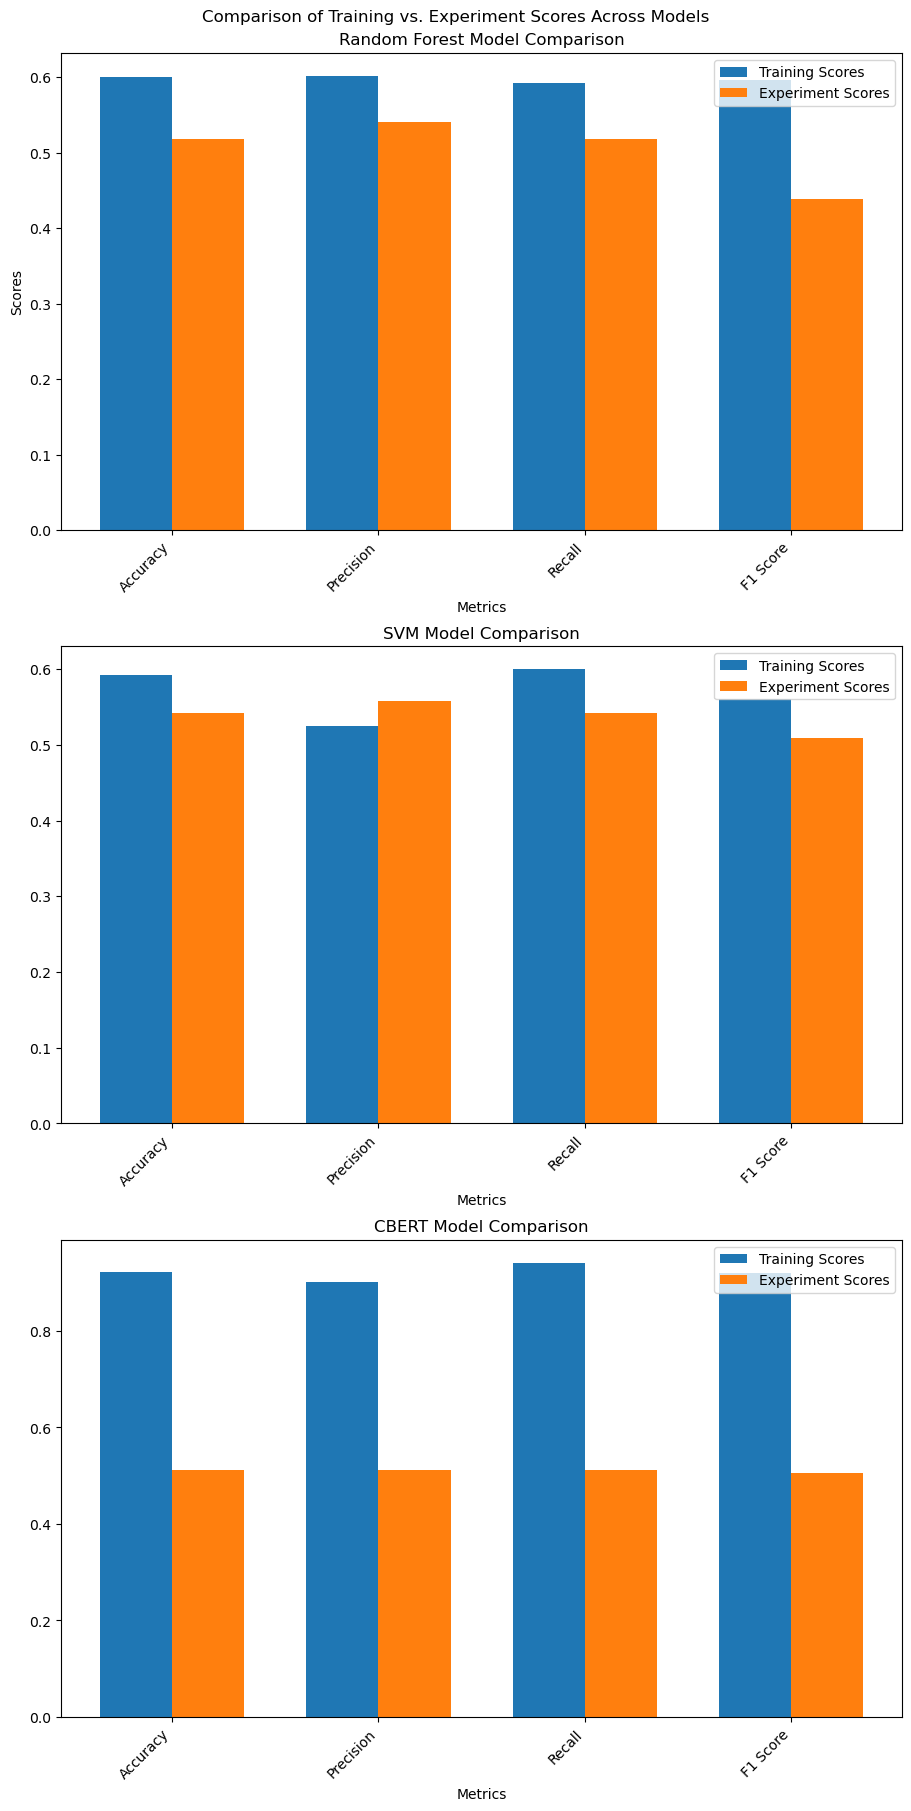

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming df_training_scores and df_experiments_scores have the same structure
metrics = df_experiments_scores['Metric']
x = np.arange(len(metrics))  # X-axis positions
width = 0.35  # Width of bars

# Create subplots for each model
fig, axes = plt.subplots(3, 1, figsize=(9, 18), layout='constrained')
models = ["Random Forest Model", "SVM Model", "CBERT Model"]
colors = ['green', 'blue']

for i, model in enumerate(models):
    axes[i].bar(x - width/2, df_training_scores[model], width, label='Training Scores')
    axes[i].bar(x + width/2, df_experiments_scores[model], width, label='Experiment Scores')
    
    # Labels, title, and legend
    axes[i].set_xlabel("Metrics")
    axes[i].set_title(f"{model} Comparison")
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(metrics, rotation=45, ha='right')
    axes[i].legend()

axes[0].set_ylabel("Scores")
plt.suptitle("Comparison of Training vs. Experiment Scores Across Models")
plt.show()
# Show the plot
